In [ ]:
# This only saves the dots position
import os
import pandas as pd
from lxml import etree

# Carpeta donde están los XML
carpeta = "data"

# Función para parsear un XML y devolver un diccionario
def parse_xml(ruta):
    tree = etree.parse(ruta)
    root = tree.getroot()

    # función auxiliar
    def make_float(x):
        try:
            return float(x)
        except:
            return None
    fila = dict()
    for prop in root.findall("property"):
        if prop.get("name") == "Temp":
            fila["T"] = make_float(prop.text)

    
    for prop in ["X",'Y','Z']:
        xpath = f".//property[@name='{prop}']/property[@name='array']"
        element = root.find(xpath)
        clean_str = element.text.strip("{}")
        fila[prop.lower()] = np.fromstring(clean_str, sep=',')



    return fila

def save_experiment(data):
    # 1. Create the filename from the ID
    # We cast to int if the float represents a whole number ID
    filename = f"graph_points/{data['T']}.npz"
    
    # 2. Save the arrays into one compressed file
    # You can label the keyword arguments so they are easy to load later
    np.savez_compressed(
        filename, 
        x=data['x'], 
        y=data['y'], 
        z=data['z']
    )
    print(f"Saved: {filename}")

# Leer todos los XML
filas = []

# for archivo in os.listdir(carpeta):
#     if archivo.endswith(".xml"):
#         ruta = os.path.join(carpeta, archivo)
#         current_file = parse_xml(ruta)
#         save_experiment(current_file)

Saved: graph_points/0.0424.npz
Saved: graph_points/0.0847.npz
Saved: graph_points/0.1271.npz
Saved: graph_points/0.1695.npz
Saved: graph_points/0.2119.npz
Saved: graph_points/0.2542.npz
Saved: graph_points/0.2966.npz
Saved: graph_points/0.339.npz
Saved: graph_points/0.3814.npz
Saved: graph_points/0.4.npz
Saved: graph_points/0.4237.npz
Saved: graph_points/0.4661.npz
Saved: graph_points/0.5.npz
Saved: graph_points/0.5085.npz
Saved: graph_points/0.5508.npz
Saved: graph_points/0.5932.npz
Saved: graph_points/0.6356.npz
Saved: graph_points/0.678.npz
Saved: graph_points/0.7203.npz
Saved: graph_points/0.7627.npz
Saved: graph_points/0.8051.npz
Saved: graph_points/0.8475.npz
Saved: graph_points/0.8898.npz
Saved: graph_points/0.9322.npz
Saved: graph_points/0.9746.npz
Saved: graph_points/1.0169.npz
Saved: graph_points/1.0593.npz
Saved: graph_points/1.1017.npz
Saved: graph_points/1.1441.npz
Saved: graph_points/1.1864.npz
Saved: graph_points/1.2288.npz
Saved: graph_points/1.2712.npz
Saved: graph_poi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv("resultados.csv")
df.columns = df.columns.str.strip()
df = df.drop(columns=["file","N","rho"])
index_errors = [0,12,16]
df = df.sort_values("T").reset_index(drop=True)
df = df.loc[~df.index.isin(index_errors)].reset_index(drop=True)
df


,T,P,K,U,U_err,P_err,V,rcut,mu_ex,beta_mu_ex_err,mu_c,mu_t,beta_mu_ex
0,0.0200,-1.401747,0.03000,-7.472754,0.029290,0.199212,625.0,4.0,-10.046103,10.742945,-10.050565,-10.208478,-502.305136
1,0.0400,-1.669266,0.06000,-7.361085,0.014536,0.085521,625.0,4.0,-10.925912,2.604218,-10.934838,-11.250663,-273.147805
2,0.0424,-2.221438,0.06360,-7.266463,0.072734,0.172446,625.0,4.0,-12.421253,16.858863,-12.430714,-12.765489,-292.954083
3,0.0600,-1.369538,0.09000,-7.377471,0.014626,0.072600,625.0,4.0,-11.579578,4.969190,-11.592967,-12.066704,-192.992975
4,0.0800,-1.427452,0.12000,-7.332818,0.013489,0.071085,625.0,4.0,-9.837956,1.343933,-9.855807,-10.487456,-122.974444
...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,3.3876,10.174217,5.08140,-3.853084,0.116274,0.488475,625.0,4.0,12.613390,0.042087,11.857469,-14.889718,3.723400
131,3.4299,10.320460,5.14485,-3.826179,0.119103,0.494612,625.0,4.0,12.605011,0.086574,11.839651,-15.241520,3.675038
132,3.4722,10.424553,5.20830,-3.808182,0.120670,0.499262,625.0,4.0,13.239559,0.049370,12.464760,-14.950396,3.813017
133,3.5145,10.564238,5.27175,-3.782201,0.116547,0.481139,625.0,4.0,13.362528,0.063022,12.578290,-15.170851,3.802114


0      0.0200
1      0.0400
2      0.0424
3      0.0600
4      0.0800
        ...  
130    3.3876
131    3.4299
132    3.4722
133    3.5145
134    3.5568
Name: T, Length: 135, dtype: float64


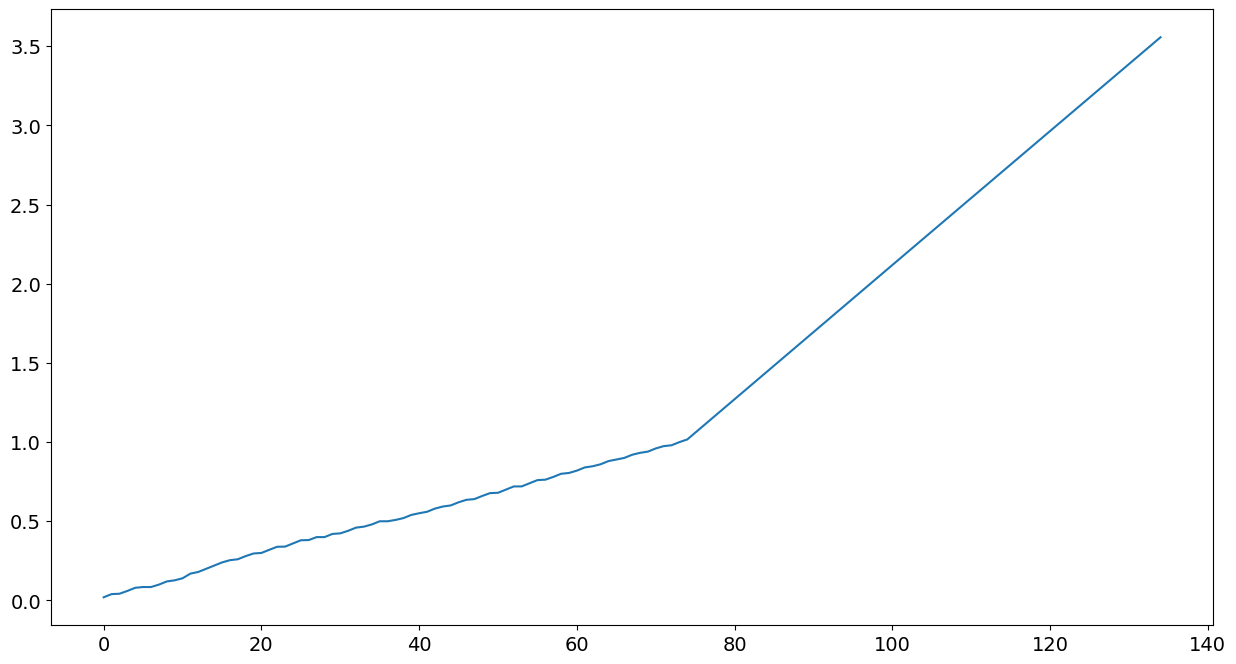

In [21]:
print(df["T"])
plt.plot(df["T"])
plt.show()

Index(['T', 'P', 'K', 'U', 'U_err', 'P_err', 'V', 'rcut', 'mu_ex',
       'beta_mu_ex_err', 'mu_c', 'mu_t', 'beta_mu_ex'],
      dtype='str')


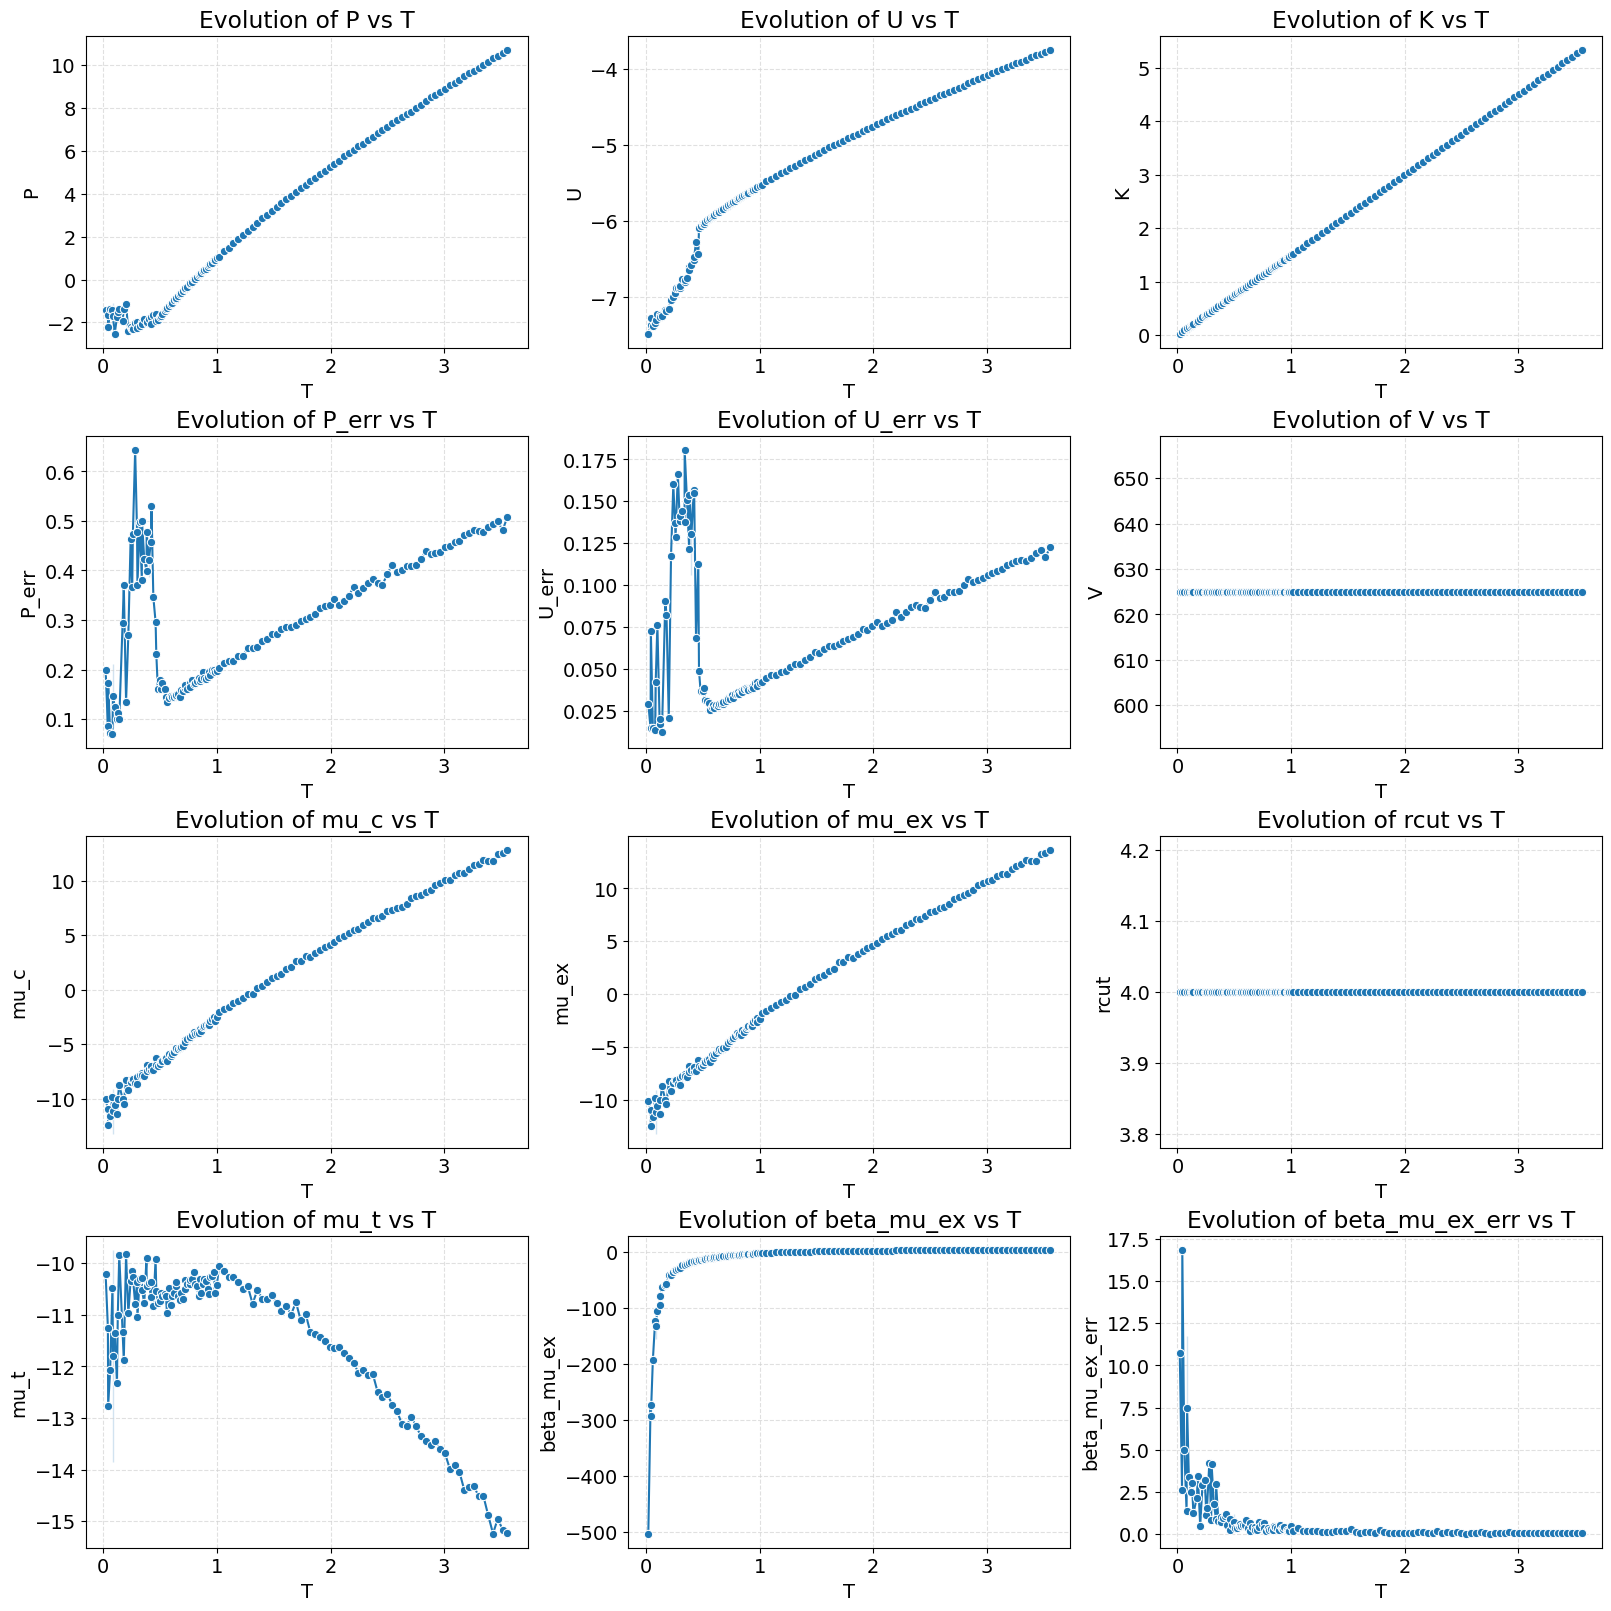

In [22]:
# Logic to plot each variable against 'T'
y_vars = [col for col in df.columns if col != 'T']
n_vars = len(y_vars)
n_cols = 12
print(df.columns)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 4 * 4), constrained_layout=True)

prettier_order = ['P','U','K','P_err','U_err','V','mu_c','mu_ex','rcut','mu_t','beta_mu_ex','beta_mu_ex_err']

for i, var in enumerate(prettier_order):
    x = i//3
    y = i % 3
    ax = axes[x,y]
    sns.lineplot(data=df, x='T', y=var, ax=ax, marker='o')
    ax.set_title(f'Evolution of {var} vs T')
    ax.grid(True, linestyle='--', alpha=0.7)

fig.savefig("prova1")
plt.show()

In [26]:
def funcio_error(df,col,ax):
    x = df["T"]
    y = df[col]
    y_err = df[f"{col}_err"]
    ax.errorbar(x,y,y_err,
        label=f"{col}",
        capthick = 1,
        ecolor="red",  # Color barra d'error
        capsize = 5,  # tamany de la linia perpendicular a l'error
        color="darkblue",
        fmt=".",  # tipus de linia
        linewidth=0.5,
        )
    ax.set_xlabel("T")
    ax.set_ylabel(col)
    ax.set_title(f"Evolució {col} respecte T")
    return ax

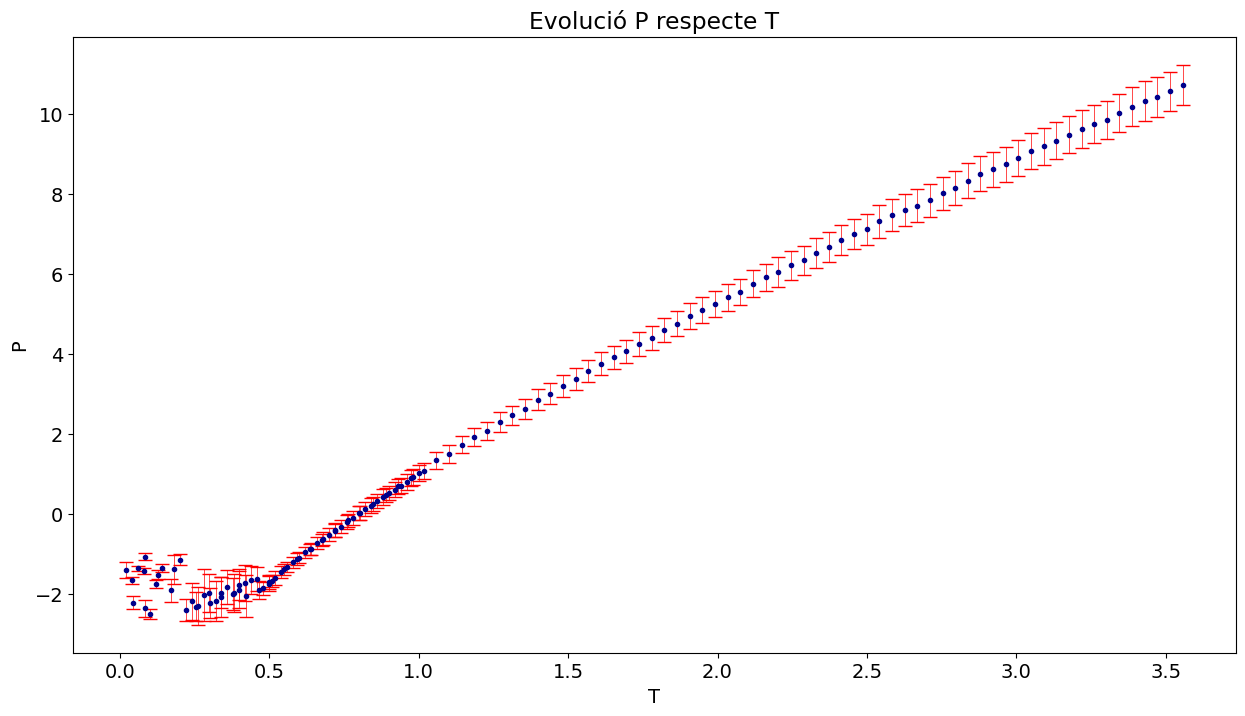

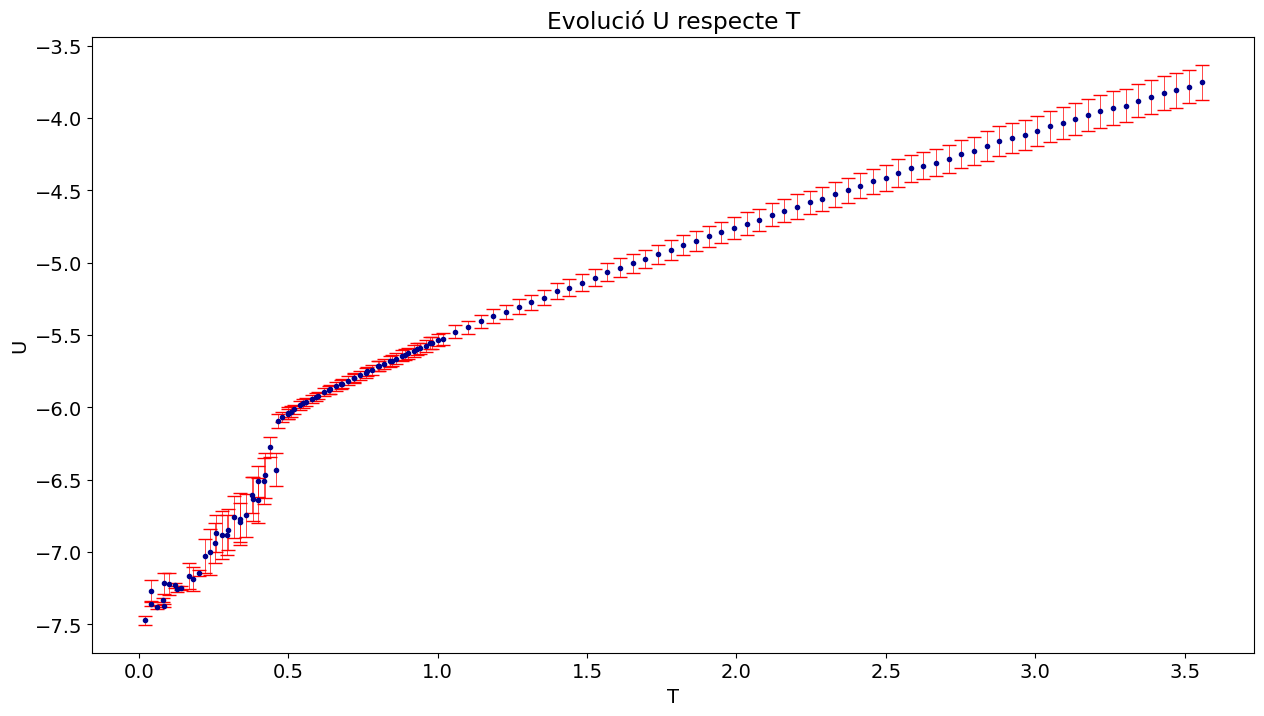

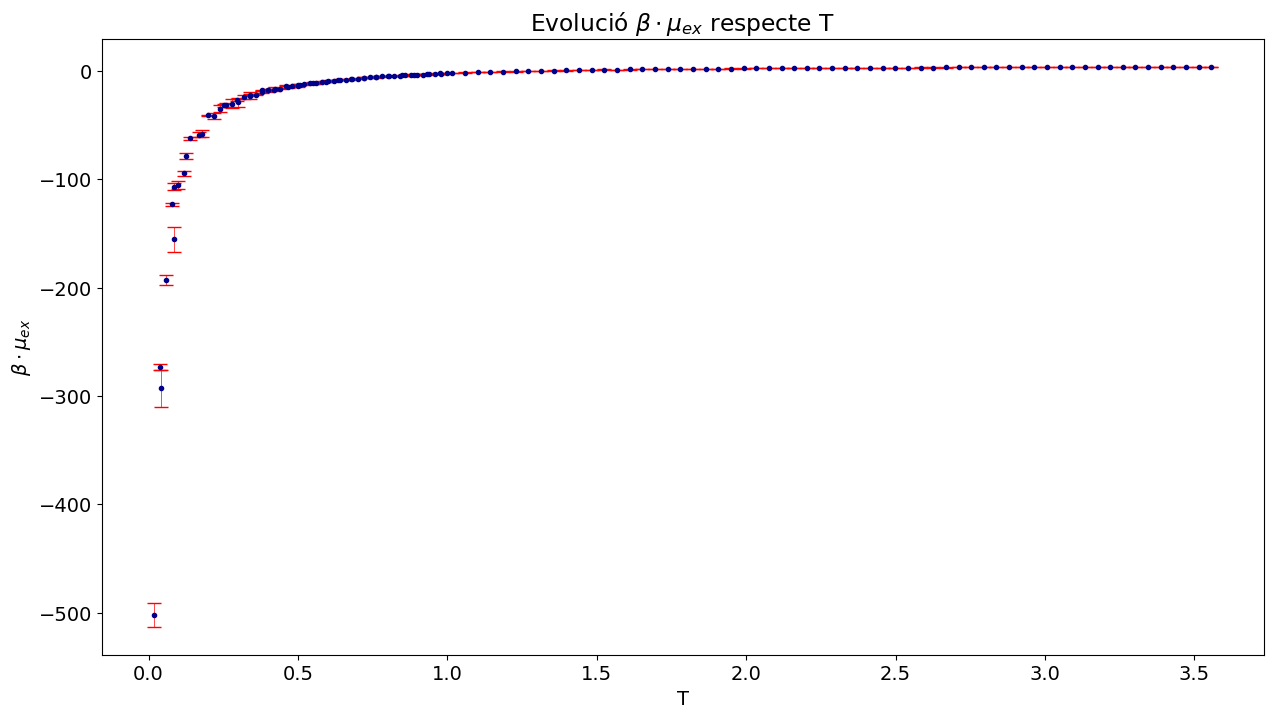

In [31]:
plt.rcParams["figure.figsize"] = (15,8)
plt.rcParams["grid.color"] = "lightgray"
plt.rcParams["font.size"] = 14
plt.rcParams["figure.titlesize"] = 25

fig,ax = plt.subplots(1,1,figsize=(15,8))
funcio_error(df,"P",ax)
fig.savefig("prova2.png")
plt.show()
fig,ax = plt.subplots(1,1,figsize=(15,8))
funcio_error(df,"U",ax)
fig.savefig("prova2.png")
plt.show()
fig,ax = plt.subplots(1,1,figsize=(15,8))
funcio_error(df,"beta_mu_ex",ax)
ax.set_ylabel(r"$\beta\cdot\mu_{ex}$")
ax.set_title(r"Evolució $\beta\cdot\mu_{ex}$ respecte T")
fig.savefig("prova2.png")
plt.show()

In [2]:
def maxwell_boltzmann_pdf(v, T, m):
    """Calculates the MB probability density for a given speed v."""
    k_B = 1.38e-23
    # Pre-factor term
    a = (m / (2 * np.pi * k_B * T))**1.5
    # The distribution formula
    return a * 4 * np.pi * v**2 * np.exp(-m * v**2 / (2 * k_B * T))

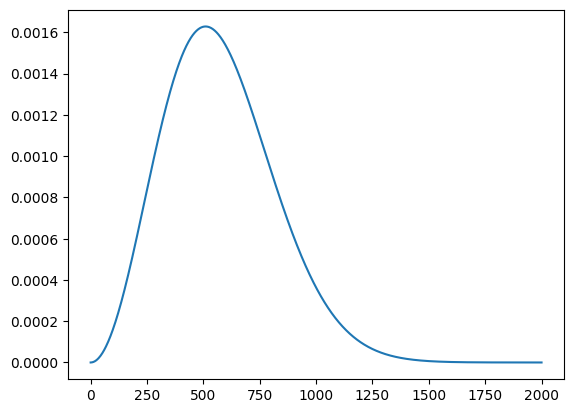

In [3]:
vel = np.linspace(0,2e3,1000)
mass = 16e-3 / 6e23  # helium mass
mass = 5.31e-26  # kg (aprox O2)
result = maxwell_boltzmann_pdf(vel,500,mass)
plt.plot(vel,result)

In [ ]:
def vel_maxwell_boltzmann(T, massa, n=1):
    kB = 1.380649e-23  # constante de Boltzmann (J/K)
    
    sigma = np.sqrt(kB * T / massa)
    
    vx = np.random.normal(0, sigma, n)
    vy = np.random.normal(0, sigma, n)
    vz = np.random.normal(0, sigma, n)
    
    v = np.sqrt(vx**2 + vy**2 + vz**2)
    return v

In [6]:
T = 300
n = 1_000_000
vel = np.random.random(n)*3000
cand = np.random.random(n)/10
prob = maxwell_boltzmann_pdf(vel,T,mass)
final = vel[cand<prob]
print(final)

[247.55947867  85.80565522 407.93698705 ... 713.86334127 329.45942462
 146.27774878]


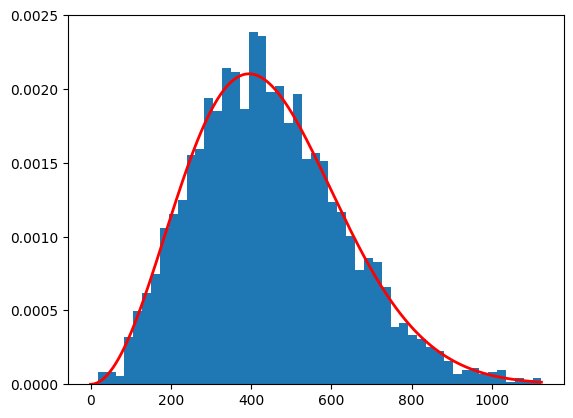

In [12]:
# Función teórica
kB = 1.380649e-23  # constante de Boltzmann (J/K)
def f_MB(v, T, m):
    return (m / (2 * np.pi * kB * T))**(3/2) * 4 * np.pi * v**2 * np.exp(-m * v**2 / (2 * kB * T))

# Valores de v para la curva
v_vals = np.linspace(0, max(final), 500)
f_vals = f_MB(v_vals, T, mass)
plt.hist(final,bins=50,density=True)
plt.plot(v_vals, f_vals, 'r-', lw=2, label="Teórica")
plt.show()